In [ ]:
# Importing required libraries
import numpy as np
import pandas as pd
import nltk
import string
import nltk
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score, roc_curve


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reading the file without headers
df = pd.read_csv('/content/drive/MyDrive/Coursework/IDATA_Coursework2/amazon_cells_labelled.txt', sep='\t', header=None)

# Setting the column names
df.columns = ['text', 'sentiment']

# Displaying the first few rows
print(df.head(10))

                                                                                                              text  \
0                               So there is no way for me to plug it in here in the US unless I go by a converter.   
1                                                                                      Good case, Excellent value.   
2                                                                                           Great for the jawbone.   
3                                  Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!   
4                                                                                                The mic is great.   
5                                       I have to jiggle the plug to get it to line up right to get decent volume.   
6  If you have several dozen or several hundred contacts, then imagine the fun of sending each of them one by one.   
7                                                       

# Preprocessing

In [ ]:
df.shape

(1000, 2)

In [ ]:
df.sentiment.value_counts()

,count
sentiment,
0,500
1,500


In [ ]:
# Assigning the sentiment's values into label
label = df['sentiment'].values
print(label[:5])

[0 1 1 0 1]


In [ ]:
df.dtypes

,0
text,object
sentiment,int64


In [ ]:


#change the text column datatype to string
df = df.astype({'text':'string'})

In [ ]:
df.dtypes

,0
text,string[python]
sentiment,int64


In [ ]:
# Adjust pandas display option
pd.set_option('display.max_colwidth', None)

In [ ]:
text = df['text']
text[:50]

,text
0,So there is no way for me to plug it in here in the US unless I go by a converter.
1,"Good case, Excellent value."
2,Great for the jawbone.
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!
4,The mic is great.
5,I have to jiggle the plug to get it to line up right to get decent volume.
6,"If you have several dozen or several hundred contacts, then imagine the fun of sending each of them one by one."
7,If you are Razr owner...you must have this!
8,"Needless to say, I wasted my money."
9,What a waste of money and time!.


## Removing Punctuation

In [ ]:
text1 = []

for df in text:
    #remove punctuation
    df = df.translate(str.maketrans('', '', string.punctuation))
    text1.append(df)
text1[:50]

['So there is no way for me to plug it in here in the US unless I go by a converter',
 'Good case Excellent value',
 'Great for the jawbone',
 'Tied to charger for conversations lasting more than 45 minutesMAJOR PROBLEMS',
 'The mic is great',
 'I have to jiggle the plug to get it to line up right to get decent volume',
 'If you have several dozen or several hundred contacts then imagine the fun of sending each of them one by one',
 'If you are Razr owneryou must have this',
 'Needless to say I wasted my money',
 'What a waste of money and time',
 'And the sound quality is great',
 'He was very impressed when going from the original battery to the extended battery',
 'If the two were seperated by a mere 5 ft I started to notice excessive static and garbled sound from the headset',
 'Very good quality though',
 'The design is very odd as the ear clip is not very comfortable at all',
 'Highly recommend for any one who has a blue tooth phone',
 'I advise EVERYONE DO NOT BE FOOLED',
 'So F

## Removing Numbers

In [ ]:
text2 = []

for df in text1:
    # remove digits/numbers
    df = df.translate(str.maketrans('', '', string.digits))
    #print(sentence)
    text2.append(df)


text2[:50]

['So there is no way for me to plug it in here in the US unless I go by a converter',
 'Good case Excellent value',
 'Great for the jawbone',
 'Tied to charger for conversations lasting more than  minutesMAJOR PROBLEMS',
 'The mic is great',
 'I have to jiggle the plug to get it to line up right to get decent volume',
 'If you have several dozen or several hundred contacts then imagine the fun of sending each of them one by one',
 'If you are Razr owneryou must have this',
 'Needless to say I wasted my money',
 'What a waste of money and time',
 'And the sound quality is great',
 'He was very impressed when going from the original battery to the extended battery',
 'If the two were seperated by a mere  ft I started to notice excessive static and garbled sound from the headset',
 'Very good quality though',
 'The design is very odd as the ear clip is not very comfortable at all',
 'Highly recommend for any one who has a blue tooth phone',
 'I advise EVERYONE DO NOT BE FOOLED',
 'So Far 

## Changing text to lower case

In [ ]:
text3 = []

for df in text2:
    #change to lowercase
    df = df.lower()
    #print(sentence)
    text3.append(df)


text3[:50]

['so there is no way for me to plug it in here in the us unless i go by a converter',
 'good case excellent value',
 'great for the jawbone',
 'tied to charger for conversations lasting more than  minutesmajor problems',
 'the mic is great',
 'i have to jiggle the plug to get it to line up right to get decent volume',
 'if you have several dozen or several hundred contacts then imagine the fun of sending each of them one by one',
 'if you are razr owneryou must have this',
 'needless to say i wasted my money',
 'what a waste of money and time',
 'and the sound quality is great',
 'he was very impressed when going from the original battery to the extended battery',
 'if the two were seperated by a mere  ft i started to notice excessive static and garbled sound from the headset',
 'very good quality though',
 'the design is very odd as the ear clip is not very comfortable at all',
 'highly recommend for any one who has a blue tooth phone',
 'i advise everyone do not be fooled',
 'so far 

In [ ]:
text1 = pd.Series(text3)
text1[:5]

,0
0,so there is no way for me to plug it in here in the us unless i go by a converter
1,good case excellent value
2,great for the jawbone
3,tied to charger for conversations lasting more than minutesmajor problems
4,the mic is great


## Remove stop words
    

In [ ]:
#Setting English stopwords
stop_words = set(stopwords.words('english'))

text1 = text1.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))
text1[:15]

,0
0,way plug us unless go converter
1,good case excellent value
2,great jawbone
3,tied charger conversations lasting minutesmajor problems
4,mic great
5,jiggle plug get line right get decent volume
6,several dozen several hundred contacts imagine fun sending one one
7,razr owneryou must
8,needless say wasted money
9,waste money time


## Apply lemmatising with POS tags

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
#text1 = text1.apply(lambda x: word_tokenize(x))
text1[:50]

,0
0,way plug us unless go converter
1,good case excellent value
2,great jawbone
3,tied charger conversations lasting minutesmajor problems
4,mic great
5,jiggle plug get line right get decent volume
6,several dozen several hundred contacts imagine fun sending one one
7,razr owneryou must
8,needless say wasted money
9,waste money time


In [ ]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
def get_wordnet_pos(word):
    #Map POS tag to first character lemmatize() accepts
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

# Init the Wordnet Lemmatizer
lemmatizer = WordNetLemmatizer()
text4 = text1.apply(lambda x:' '.join(lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in x.split()))
text4[:50] #notice that it does a better job

,0
0,way plug u unless go converter
1,good case excellent value
2,great jawbone
3,tie charger conversation last minutesmajor problem
4,mic great
5,jiggle plug get line right get decent volume
6,several dozen several hundred contact imagine fun send one one
7,razr owneryou must
8,needless say waste money
9,waste money time


In [ ]:
df1 = list(zip(text4, label))

reviewsP = pd.DataFrame (df1, columns = ['Review', 'Sentiment'])
reviewsP

,Review,Sentiment
0,way plug u unless go converter,0
1,good case excellent value,1
2,great jawbone,1
3,tie charger conversation last minutesmajor problem,0
4,mic great,1
...,...,...
995,screen get smudge easily touch ear face,0
996,piece junk lose call phone,0
997,item match picture,0
998,thing disappoint infra red port irda,0


In [ ]:
reviewsP.Sentiment.value_counts()

,count
Sentiment,
0,500
1,500


# Classification

In [ ]:
reviewsP.head()

,Review,Sentiment
0,way plug u unless go converter,0
1,good case excellent value,1
2,great jawbone,1
3,tie charger conversation last minutesmajor problem,0
4,mic great,1


In [ ]:
#split the dataset

#train dataset by splitting the data
train_reviews = reviewsP.Review[:800]
train_sentiments = reviewsP.Sentiment[:800]

#test dataset
test_reviews = reviewsP.Review[200:]
test_sentiments = reviewsP.Sentiment[200:]

print(train_reviews.shape,train_sentiments.shape)
print(test_reviews.shape,test_sentiments.shape)

(800,) (800,)
(800,) (800,)


In [ ]:
train_reviews[0]

'way plug u unless go converter'

## Transform text into BoW with count features

In [ ]:
#Count vectorizer for bag of words

cv = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=0.01,
    max_df=0.9)

#transformed train reviews
cv_train_reviews=cv.fit_transform(train_reviews)
#transformed test reviews
cv_test_reviews=cv.transform(test_reviews)

print('BOW_cv_train:',cv_train_reviews.shape)
print('BOW_cv_test:',cv_test_reviews.shape)

BOW_cv_train: (800, 110)
BOW_cv_test: (800, 110)


In [ ]:
print(cv_train_reviews[0])

  (0, 77)	1
  (0, 42)	1


## RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)


#Fitting the model for Bag of words
rf_bow = rf.fit(cv_train_reviews,train_sentiments)

#Predicting the model for bag of words
rf_bow_predict=rf.predict(cv_test_reviews)


#Classification report for bag of words
rf_bow_report=classification_report(test_sentiments,rf_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,rf_bow_predict), '\n')
print(rf_bow_report)

#Accuracy score for bag of words
rf_bow_score=accuracy_score(test_sentiments,rf_bow_predict)
print("rf_bow accuracy :",rf_bow_score)
print("AUC:", roc_auc_score(test_sentiments, rf_bow_predict))

[[363  38]
 [ 61 338]] 

              precision    recall  f1-score   support

    Positive       0.86      0.91      0.88       401
    Negative       0.90      0.85      0.87       399

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800

rf_bow accuracy : 0.87625
AUC: 0.8761773511084443


## Naive Bayes

In [ ]:

NB = MultinomialNB()

#Fitting the model for Bag of words
NB_bow = NB.fit(cv_train_reviews,train_sentiments)

#Predicting the model for bag of words
NB_bow_predict = NB.predict(cv_test_reviews)

#Classification report for bag of words
NB_bow_report=classification_report(test_sentiments,NB_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,NB_bow_predict), '\n')
print(NB_bow_report)
#Accuracy score for bag of words
NB_bow_score=accuracy_score(test_sentiments,NB_bow_predict)
print("NB_bow accuracy :",NB_bow_score)
print("AUC:", roc_auc_score(test_sentiments, NB_bow_predict))

[[247 154]
 [ 78 321]] 

              precision    recall  f1-score   support

    Positive       0.76      0.62      0.68       401
    Negative       0.68      0.80      0.73       399

    accuracy                           0.71       800
   macro avg       0.72      0.71      0.71       800
weighted avg       0.72      0.71      0.71       800

NB_bow accuracy : 0.71
AUC: 0.710235688973056


## SVM

In [ ]:
#SVM
SVM = SGDClassifier(loss='hinge',max_iter=500,random_state=42)

#Fitting the model for Bag of words
SVM_bow = SVM.fit(cv_train_reviews,train_sentiments)

#Predicting the model for bag of words
SVM_bow_predict = SVM.predict(cv_test_reviews)

#Classification report for bag of words
SVM_bow_report=classification_report(test_sentiments,SVM_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,SVM_bow_predict), '\n')
print(SVM_bow_report)
#Accuracy score for bag of words
SVM_bow_score=accuracy_score(test_sentiments,SVM_bow_predict)
print("SVM_bow accuracy :",SVM_bow_score)
print("AUC:", roc_auc_score(test_sentiments, SVM_bow_predict))

[[345  56]
 [106 293]] 

              precision    recall  f1-score   support

    Positive       0.76      0.86      0.81       401
    Negative       0.84      0.73      0.78       399

    accuracy                           0.80       800
   macro avg       0.80      0.80      0.80       800
weighted avg       0.80      0.80      0.80       800

SVM_bow accuracy : 0.7975
AUC: 0.7973424833905213


## XGboost

In [ ]:
from xgboost import XGBClassifier # Import the XGBClassifier class directly
from sklearn.metrics import accuracy_score

XG = XGBClassifier(n_estimators=200,max_depth=6)

#Fitting the model for Bag of words
XG_bow = XG.fit(cv_train_reviews,train_sentiments)

#Predicting the model for bag of words
XG_bow_predict = XG.predict(cv_test_reviews)

#Classification report for bag of words
XG_bow_report=classification_report(test_sentiments,XG_bow_predict,target_names=['Positive','Negative'])
print(confusion_matrix(test_sentiments,XG_bow_predict), '\n')
print(XG_bow_report)
#Accuracy score for bag of words
XG_bow_score=accuracy_score(test_sentiments,XG_bow_predict)
print("NB_bow accuracy :",XG_bow_score)
print("AUC:", roc_auc_score(test_sentiments, XG_bow_predict))

[[357  44]
 [ 88 311]] 

              precision    recall  f1-score   support

    Positive       0.80      0.89      0.84       401
    Negative       0.88      0.78      0.82       399

    accuracy                           0.83       800
   macro avg       0.84      0.83      0.83       800
weighted avg       0.84      0.83      0.83       800

NB_bow accuracy : 0.835
AUC: 0.8348614678841743


# Bert

In [ ]:
# A dependency of the preprocessing for BERT inputs
!pip install tensorflow==2.15.1
!pip install tensorflow-text==2.15.0
!pip install tf-models-official==2.15
!pip install transformers==4.24.0

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization  # to create AdamW optimizer

import matplotlib.pyplot as plt


In [ ]:
from sklearn.model_selection import train_test_split

#split and take the test set
X, X_test, y, y_test = (train_test_split(reviewsP['Review'], reviewsP['Sentiment'],
                                                     stratify=reviewsP['Sentiment'],
                                                     test_size=0.2,
                                                     train_size=0.8
                                                     ))



In [ ]:

#split the train set (X) into train and validation
X_train, X_val, y_train, y_val = (train_test_split(X, y,
                                                     stratify=y,
                                                     test_size=0.25,
                                                     train_size=0.75
                                                     ))


In [ ]:
X_train

,Review
699,comfortable fit need headset comfortable least hour time entire day
965,cannot make call certain place
588,use two day wasnt always easy hear
416,awesome new look fall
533,basically threw money window nothing
...,...
307,many people complain found headset microphone weak
895,quite comfortable ear
835,call drop phone come screen go black bad stop ring intermittently
497,save money ive item month


In [ ]:
X_val

,Review
944,maintain connection computer lap
536,bluetooth range good day ago left phone trunk get call carry conversation without hitch
806,first thought grtting good deal plug phone vc razr
356,thing think could improve sound leak headset
517,receive order well within shipping timeframe everything good work order overall excite source
...,...
787,simple use like
958,really like product motorola allot clearer ear piece mic
543,dont buy product
874,good quality


In [ ]:
X_test

,Review
796,five star plus plus
610,doesnt work europe asia
460,bt battery junk
116,get phone around end may im completely unhappy
222,simple lightweight great fit
...,...
655,ear loop need tiny sound great
25,great pocket pc phone combination
697,doesnt make look cool
182,sound quality good functionality awesome


In [ ]:
#@title Choose a BERT model to fine-tune

#the model has 5 layers (L), 512 hidden size H and 8 attention heads
bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'

map_name_to_handle = {
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
}

map_model_to_preprocess = {
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


In [ ]:
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)

In [ ]:
reviewsP['Review'][0]

'way plug u unless go converter'

In [ ]:
text_test = ['way plug u unless go converter']
text_preprocessed = bert_preprocess_model(text_test)

print(f'Keys       : {list(text_preprocessed.keys())}')
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}')
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :12]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :12]}')
print(f'Type Ids   : {text_preprocessed["input_type_ids"][0, :12]}')

Keys       : ['input_type_ids', 'input_mask', 'input_word_ids']
Shape      : (1, 128)
Word Ids   : [  101  2126 13354  1057  4983  2175 10463  2121   102     0     0     0]
Input Mask : [1 1 1 1 1 1 1 1 1 0 0 0]
Type Ids   : [0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
bert_model = hub.KerasLayer(tfhub_handle_encoder)

In [ ]:
bert_results = bert_model(text_preprocessed)

print(f'Loaded BERT: {tfhub_handle_encoder}')
print(f'Pooled Outputs Shape:{bert_results["pooled_output"].shape}')
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :12]}')
print(f'Sequence Outputs Shape:{bert_results["sequence_output"].shape}')
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :12]}')

Loaded BERT: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Pooled Outputs Shape:(1, 512)
Pooled Outputs Values:[ 0.99391407  0.9832326   0.21593706  0.13459668  0.50391203  0.9713764
  0.9584971  -0.99840206 -0.32061917 -0.99925804  0.25281537 -0.9042483 ]
Sequence Outputs Shape:(1, 128, 512)
Sequence Outputs Values:[[-0.11911385 -0.22376382  0.43766642 ... -0.5142637   0.14734387
  -0.14175957]
 [-0.70305675  0.7343803   0.3433788  ...  0.3256812   0.43783358
   0.1779912 ]
 [-1.123277   -0.3096478  -0.09063612 ... -0.42509627 -0.24610856
   0.15283194]
 ...
 [ 0.1718982   0.665375    0.33678123 ...  0.17453244  0.56197953
  -0.06585474]
 [-0.07886058  0.68737423  0.4023561  ...  0.24412696  0.41194624
  -0.12597997]
 [-0.16986644  0.81598425  0.5660151  ... -0.06763931  0.6258653
  -0.04610712]]


In [ ]:
def build_classifier_model():
  text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
  preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
  encoder_inputs = preprocessing_layer(text_input)
  encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
  outputs = encoder(encoder_inputs)
  net = outputs['pooled_output']
  net = tf.keras.layers.Dropout(0.1)(net)
  net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
  #net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)
  return tf.keras.Model(text_input, net)

classifier_model = build_classifier_model()

In [ ]:
classifier_model = build_classifier_model()

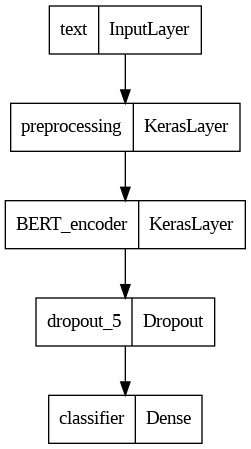

In [ ]:
tf.keras.utils.plot_model(classifier_model)

In [ ]:
epochs = 10
steps_per_epoch = 1200  #corresponding to the train set size
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps) #10% of num_train_steps

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')


In [ ]:
#fine-tune BERT for classification
classifier_model.compile(optimizer,
                     loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                     metrics=[tf.keras.metrics.BinaryAccuracy()])
classifier_model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

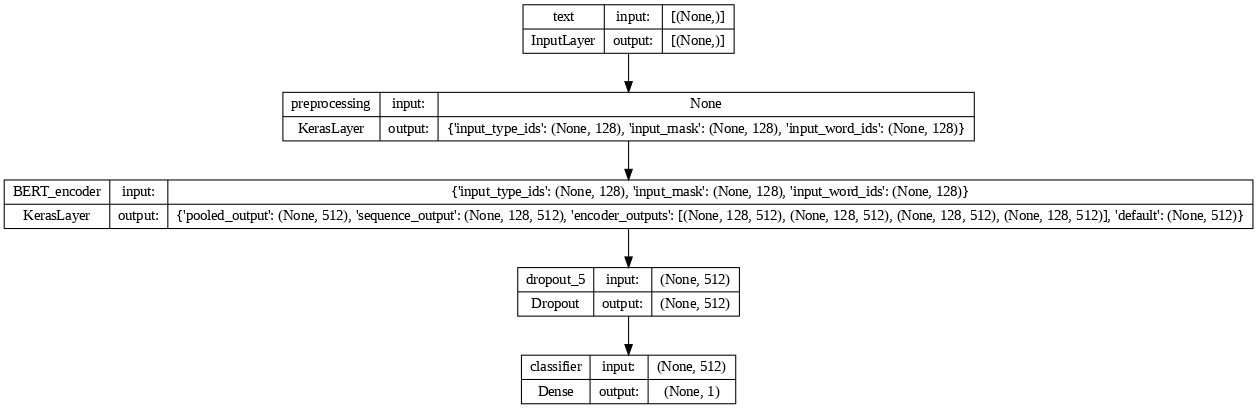

In [ ]:
tf.keras.utils.plot_model(model=classifier_model,show_shapes=True,dpi=76)

In [ ]:
print(f'Training model with {tfhub_handle_encoder}')
history = classifier_model.fit(X_train,
                               y_train,
                               validation_data=(X_val, y_val),
                               epochs=epochs)

Training model with https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/backend.py:5818: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


19/19 [==============================] - 13s 263ms/step - loss: 0.7842 - binary_accuracy: 0.4883 - val_loss: 0.7436 - val_binary_accuracy: 0.5000
Epoch 2/10
19/19 [==============================] - 5s 291ms/step - loss: 0.7623 - binary_accuracy: 0.5067 - val_loss: 0.7243 - val_binary_accuracy: 0.5150
Epoch 3/10
19/19 [==============================] - 5s 248ms/step - loss: 0.7580 - binary_accuracy: 0.4733 - val_loss: 0.7055 - val_binary_accuracy: 0.5100
Epoch 4/10
19/19 [==============================] - 5s 244ms/step - loss: 0.7168 - binary_accuracy: 0.5167 - val_loss: 0.6893 - val_binary_accuracy: 0.5300
Epoch 5/10
19/19 [==============================] - 5s 285ms/step - loss: 0.7153 - binary_accuracy: 0.5250 - val_loss: 0.6688 - val_binary_accuracy: 0.5550
Epoch 6/10
19/19 [==============================] - 4s 237ms/step - loss: 0.6578 - binary_accuracy: 0.5933 - val_loss: 0.6475 - val_binary_accuracy: 0.5900
Epoch 7/10
19/19 [==============================] - 5s 239ms/step - loss: 

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


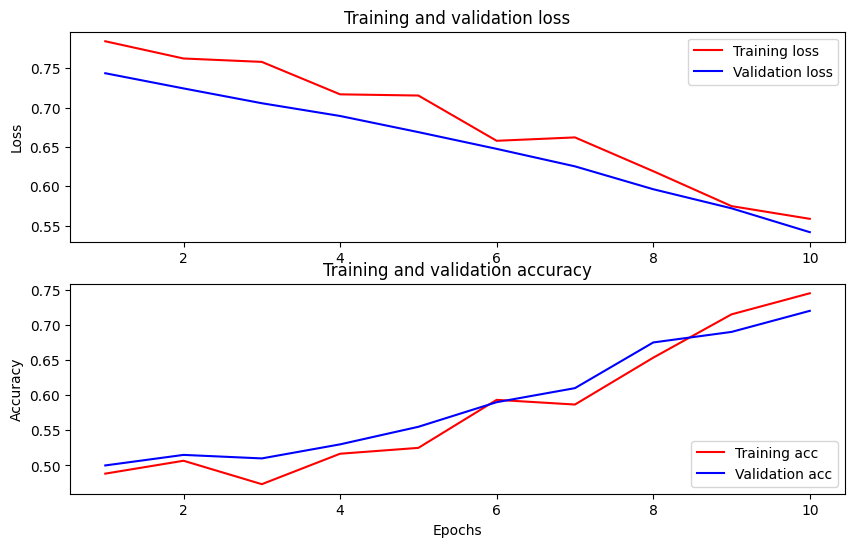

In [ ]:
history_dict = history.history
print(history_dict.keys())

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)
fig = plt.figure(figsize=(10, 6))
fig.tight_layout()

plt.subplot(2, 1, 1)
# r is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
# plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [ ]:
loss, accuracy = classifier_model.evaluate(X_test, y_test)

print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

7/7 [==============================] - 1s 97ms/step - loss: 0.5569 - binary_accuracy: 0.7350
Loss: 0.556938886642456
Accuracy: 0.7350000143051147


In [ ]:
#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#predicted values using the model
y_pred=classifier_model.predict(X_test)

print(y_pred.flatten())

7/7 [==============================] - 1s 84ms/step
[0.68241423 0.12319486 0.196114   0.18984017 0.832084   0.76937807
 0.78182393 0.77151024 0.46574497 0.4093931  0.23009469 0.88471913
 0.4495336  0.640718   0.3541596  0.40425766 0.39216557 0.2832145
 0.51521385 0.3722087  0.41219977 0.3459812  0.33312562 0.6510281
 0.7862777  0.25023603 0.7605776  0.4310951  0.28028065 0.51808614
 0.41475952 0.74721694 0.61012733 0.60698915 0.7564792  0.27521938
 0.15294081 0.35833475 0.5927903  0.1628308  0.20016168 0.6788045
 0.7140141  0.38057914 0.33303738 0.30843323 0.30866846 0.3223517
 0.38708442 0.38941914 0.34646603 0.72432375 0.54007286 0.55262065
 0.42490342 0.49931702 0.4538735  0.46687976 0.15187544 0.80577207
 0.586584   0.8904672  0.3999823  0.40298668 0.52082783 0.20867415
 0.43242598 0.74743646 0.26200706 0.30197006 0.6477765  0.5303134
 0.23859785 0.8577247  0.39011768 0.81590927 0.4995232  0.2516801
 0.40280834 0.30022192 0.33557644 0.5421275  0.5039925  0.5741953
 0.7088557  0.201

In [ ]:
#len(y_pred)

for i in range(len(y_pred)):
  if y_pred[i]<0.5:
    y_pred[i] = 0
  else: y_pred[i] = 1

print(y_pred.flatten())

[1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1.
 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1.
 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1.
 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 1. 1. 0. 0. 1. 1.]


In [ ]:
from sklearn.metrics import roc_auc_score

print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[83 17]
 [36 64]] 

              precision    recall  f1-score   support

           0       0.70      0.83      0.76       100
           1       0.79      0.64      0.71       100

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200

Accuracy: 0.735
AUC: 0.735


## Bert Model 2

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub


def build_classifier_model_v2():
    # Input layer for text
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')

    # Preprocessing layer (unchanged)
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)

    # Encoder layer with fine-tuning disabled (for demonstration purposes)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=False, name='BERT_encoder')
    outputs = encoder(encoder_inputs)

    # Use pooled output from BERT encoder
    net = outputs['pooled_output']

    # Increased dropout rate
    net = tf.keras.layers.Dropout(0.2)(net)

    # Add an additional Dense layer for more capacity
    net = tf.keras.layers.Dense(128, activation='relu', name='dense_hidden')(net)
    net = tf.keras.layers.Dropout(0.2)(net)  # Regularization after the hidden layer

    # Classifier output layer with sigmoid activation
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)

    # Build and return the model
    return tf.keras.Model(text_input, net)

# Instantiate Model 2
classifier_model_v2 = build_classifier_model_v2()

# Compile with a different optimizer and settings
classifier_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),  # Output is a probability
    metrics=[tf.keras.metrics.BinaryAccuracy(), tf.keras.metrics.AUC()]
)

# Display the model's summary
classifier_model_v2.summary()


Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

In [ ]:
encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')


In [ ]:
print(f'Training model with {tfhub_handle_encoder}')
history_v2 = classifier_model_v2.fit(X_train,
                               y_train,
                               validation_data=(X_val, y_val),
                               epochs=10)

Training model with https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Epoch 1/10
19/19 [==============================] - 7s 172ms/step - loss: 0.8744 - binary_accuracy: 0.4983 - auc_1: 0.5103 - val_loss: 0.7584 - val_binary_accuracy: 0.4950 - val_auc_1: 0.5290
Epoch 2/10
19/19 [==============================] - 3s 151ms/step - loss: 0.7588 - binary_accuracy: 0.5150 - auc_1: 0.5235 - val_loss: 0.7040 - val_binary_accuracy: 0.5200 - val_auc_1: 0.5385
Epoch 3/10
19/19 [==============================] - 3s 180ms/step - loss: 0.7373 - binary_accuracy: 0.5067 - auc_1: 0.5212 - val_loss: 0.6908 - val_binary_accuracy: 0.5400 - val_auc_1: 0.5567
Epoch 4/10
19/19 [==============================] - 2s 131ms/step - loss: 0.7358 - binary_accuracy: 0.5133 - auc_1: 0.5128 - val_loss: 0.6845 - val_binary_accuracy: 0.5550 - val_auc_1: 0.5782
Epoch 5/10
19/19 [==============================] - 2s 129ms/step - loss: 0.6963 - binary_accuracy: 0.5567 - auc_1: 0.5799 - val_loss: 0.678

In [ ]:
#predicted values using the model
y_pred=classifier_model_v2.predict(X_test)

print(y_pred.flatten())

7/7 [==============================] - 2s 105ms/step
[0.41492832 0.44787464 0.39428863 0.51647395 0.6118955  0.6355536
 0.6344446  0.57148534 0.4631658  0.31084454 0.47947398 0.5187774
 0.50551397 0.5294992  0.38406774 0.5526739  0.54536396 0.4387781
 0.5841082  0.6265013  0.4061827  0.54288316 0.2839947  0.34815088
 0.6024276  0.47699663 0.5328506  0.30379322 0.43195397 0.48486066
 0.40919927 0.41930243 0.4295265  0.64035654 0.54099464 0.56435037
 0.4437814  0.62172985 0.52126086 0.39075065 0.43763596 0.67806745
 0.57869273 0.49310073 0.45919955 0.46474376 0.355397   0.6750433
 0.3553795  0.4616152  0.6706519  0.46072015 0.67398626 0.4008823
 0.46115416 0.4456849  0.5445396  0.44838074 0.2619331  0.53503495
 0.56505686 0.54906017 0.54202574 0.45766073 0.44329295 0.36163232
 0.483523   0.7080976  0.42499408 0.52177227 0.598628   0.44725192
 0.42973763 0.6546682  0.59064937 0.41789904 0.44454828 0.36053663
 0.45745507 0.43092817 0.529029   0.610415   0.54292953 0.5275957
 0.39353472 0.5

In [ ]:
for i in range(len(y_pred)):
  if y_pred[i]<0.5:
    y_pred[i] = 0
  else: y_pred[i] = 1

print(y_pred.flatten())

[0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0.
 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0.
 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1.
 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0.
 1. 1. 1. 0. 1. 0. 1. 1.]


In [ ]:
from sklearn.metrics import roc_auc_score

print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))


[[67 33]
 [36 64]] 

              precision    recall  f1-score   support

           0       0.65      0.67      0.66       100
           1       0.66      0.64      0.65       100

    accuracy                           0.66       200
   macro avg       0.66      0.66      0.65       200
weighted avg       0.66      0.66      0.65       200

Accuracy: 0.655
AUC: 0.655


# Topic Detection

## LDA

In [ ]:
import gensim
from gensim.utils import simple_preprocess

In [ ]:
data = reviewsP.Review.values.tolist()

In [ ]:
data[:5]

['way plug u unless go converter',
 'good case excellent value',
 'great jawbone',
 'tie charger conversation last minutesmajor problem',
 'mic great']

In [ ]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence)))

words = list(sent_to_words(data))

In [ ]:
print(words[:1][0][:30])

['way', 'plug', 'unless', 'go', 'converter']


In [ ]:
import gensim.corpora as corpora

# Create Dictionary
id2word = corpora.Dictionary(words)

# Create Corpus
texts = words

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)]


In [ ]:
from pprint import pprint

# number of topics
num_topics = 10

# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)

# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
#doc_lda = lda_model[corpus]

[(0,
  '0.033*"great" + 0.031*"phone" + 0.020*"quality" + 0.013*"battery" + '
  '0.012*"good" + 0.010*"nice" + 0.010*"im" + 0.010*"product" + 0.008*"price" '
  '+ 0.008*"well"'),
 (1,
  '0.036*"phone" + 0.026*"use" + 0.025*"work" + 0.021*"well" + 0.012*"great" + '
  '0.011*"battery" + 0.009*"product" + 0.008*"problem" + 0.008*"comfortable" + '
  '0.008*"get"'),
 (2,
  '0.049*"phone" + 0.019*"good" + 0.014*"work" + 0.014*"bad" + 0.011*"make" + '
  '0.010*"great" + 0.009*"one" + 0.009*"charge" + 0.008*"easy" + 0.008*"use"'),
 (3,
  '0.026*"work" + 0.020*"great" + 0.018*"well" + 0.018*"quality" + '
  '0.017*"good" + 0.014*"make" + 0.014*"phone" + 0.013*"headset" + '
  '0.011*"product" + 0.010*"call"'),
 (4,
  '0.021*"good" + 0.017*"phone" + 0.014*"product" + 0.013*"excellent" + '
  '0.011*"ive" + 0.009*"like" + 0.009*"month" + 0.009*"money" + '
  '0.008*"purchase" + 0.008*"headset"'),
 (5,
  '0.026*"work" + 0.020*"great" + 0.018*"get" + 0.012*"well" + 0.012*"battery" '
  '+ 0.012*"look" +

In [ ]:
pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 32.3 MB/s eta 0:00:00


In [ ]:
import pyLDAvis.gensim_models
import pyLDAvis

# Visualize the topics
pyLDAvis.enable_notebook()

LDAvis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)

LDAvis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
9      0.003590 -0.023491       1        1  11.932270
2     -0.105601  0.065332       2        1  11.835979
1     -0.030572 -0.006405       3        1  11.461609
3      0.029835  0.053614       4        1  10.296858
6      0.029943 -0.128700       5        1  10.006693
5      0.033485  0.009921       6        1   9.878190
8     -0.070197  0.018299       7        1   9.333488
0      0.127245  0.067519       8        1   9.033732
7      0.017333 -0.010763       9        1   8.402980
4     -0.035061 -0.045328      10        1   7.818202, topic_info=          Term        Freq       Total Category  logprob  loglift
9        great   77.000000   77.000000  Default  30.0000  30.0000
40     quality   39.000000   39.000000  Default  29.0000  29.0000
147       well   45.000000   45.000000  Default  28.0000  28.0000
64       phone  136.000000  136.000000  Default  27.0000  27.0000
165       nice   18.000000   18.000000  Default  26.0000  26.0000
..         ...         ...         ...      ...      ...      ...
178       call    1.600170   19.656211  Topic10  -5.5494   0.0404
41       sound    1.600162   35.810956  Topic10  -5.5494  -0.5594
42     battery    1.600156   37.486094  Topic10  -5.5494  -0.6052
65   recommend    1.600072   21.846644  Topic10  -5.5495  -0.0653
133        car    1.600067   14.964657  Topic10  -5.5495   0.3131

[753 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
555       4  0.751278        able
555       6  0.250426        able
85        2  0.510915  absolutely
85        5  0.510915  absolutely
142       4  0.628770          ac
...     ...       ...         ...
141       6  0.150627        year
141       7  0.075314        year
141      10  0.075314        year
1371      4  0.628763  yearsgreat
1336      6  0.640521         yes

[1438 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 3, 2, 4, 7, 6, 9, 1, 8, 5])

## LSA

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(data)

# LSA Model
lsa_model = TruncatedSVD(n_components=10, random_state=42)  # Set n_components to 10 for 10 topics
lsa_matrix = lsa_model.fit_transform(tfidf_matrix)

# Display topics
for idx, topic in enumerate(lsa_model.components_):
    print(f"Topic {idx + 1}:")
    print(" ".join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]]))  # Top 10 words per topic



Topic 1:
charger item fine battery product good price phone work great
Topic 2:
computer like charger didnt charm perfectly plug doesnt fine work
Topic 3:
case happy sound headset work excellent quality price product good
Topic 4:
good headset like love use best ive work bad phone
Topic 5:
terrible make use recommend time buy product money dont waste
Topic 6:
definitely fine case buy dont money waste price phone good
Topic 7:
happy price love item work excellent highly phone recommend product
Topic 8:
case poor money waste sound bad quality highly item recommend
Topic 9:
fit bluetooth recommend good comfortable ear easy love use headset
Topic 10:
purchase long disappointed terrible price life customer service battery bad


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
